In [1]:
import pandas as pd
import numpy as np

In [2]:
excel_file = "../data/EduPro Online Platform.xlsx"

courses = pd.read_excel(
    excel_file,
    sheet_name="Courses"
)

In [3]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [4]:
courses["CourseCategory"].unique()

<ArrowStringArray>
[            'Programming',                  'Design',
                'Business',               'Marketing',
            'Data Science',        'Machine Learning',
           'Cybersecurity',      'Project Management',
                 'Finance', 'Artificial Intelligence',
         'Web Development',       'Digital Marketing']
Length: 12, dtype: str

In [5]:
courses["CourseLevel"].unique()

<ArrowStringArray>
['Beginner', 'Intermediate', 'Advanced']
Length: 3, dtype: str

In [10]:
def recommend_courses(
        category,
        level,
        top_n=5):

    filtered = courses[
        (courses["CourseCategory"] == category)
        &
        (courses["CourseLevel"] == level)
    ]

    filtered = filtered.sort_values(
        by=["CourseRating"],
        ascending=False
    )

    return filtered[
        [
            "CourseName",
            "CourseCategory",
            "CourseLevel",
            "CourseRating",
            "CoursePrice",
            "CourseDuration"
        ]
    ].head(top_n)

In [11]:
courses["CourseCategory"].unique()

<ArrowStringArray>
[            'Programming',                  'Design',
                'Business',               'Marketing',
            'Data Science',        'Machine Learning',
           'Cybersecurity',      'Project Management',
                 'Finance', 'Artificial Intelligence',
         'Web Development',       'Digital Marketing']
Length: 12, dtype: str

In [13]:
courses["CourseLevel"].unique()

<ArrowStringArray>
['Beginner', 'Intermediate', 'Advanced']
Length: 3, dtype: str

In [14]:
recommend_courses(
    "Programming",
    "Beginner"
)

,CourseName,CourseCategory,CourseLevel,CourseRating,CoursePrice,CourseDuration
0,Python Basics,Programming,Beginner,4.74,472.28,11.00
2,C++ for Beginners,Programming,Beginner,3.85,0.00,19.53
3,Advanced Python,Programming,Beginner,2.88,0.00,45.13
4,Full Stack Development,Programming,Beginner,1.28,0.00,28.68


In [8]:
learner_profile = pd.read_csv(
    "../outputs/learner_profile.csv"
)

In [15]:
learner_profile.head()

,UserID,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel,Cluster,Segment
0,U00001,1,394.26,1,1.350000,2,2,3,Career Focused Learners
1,U00002,1,0.00,1,2.880000,9,1,0,Inactive Learners
2,U00003,11,613.98,7,2.889091,8,0,1,Premium Power Learners
3,U00004,13,982.05,8,3.451538,5,2,1,Premium Power Learners
4,U00005,2,346.71,2,2.055000,9,0,0,Inactive Learners


In [16]:
top_courses = (
    courses
    .groupby("CourseCategory")
    .apply(
        lambda x: x.nlargest(
            3,
            "CourseRating"
        )
    )
)

In [17]:
top_courses

CourseID                        CourseName  \
CourseCategory                                                          
Artificial Intelligence 49  CR00050                   Computer Vision   
                        47  CR00048                         AI Ethics   
                        48  CR00049                     Deep Learning   
Business                11  CR00012                 Business Strategy   
                        13  CR00014                     Sales Mastery   
                        10  CR00011              Entrepreneurship 101   
Cybersecurity           34  CR00035         Cyber Threat Intelligence   
                        32  CR00033        Cybersecurity Fundamentals   
                        31  CR00032                   Ethical Hacking   
Data Science            24  CR00025              Statistical Analysis   
                        21  CR00022                Data Visualization   
                        20  CR00021         Data Analysis with Python   
Design                  8   CR00009           Web Design Fundamentals   
                        9   CR00010                       3D Modeling   
                        5   CR00006             Graphic Design Basics   
Digital Marketing       58  CR00059               Affiliate Marketing   
                        57  CR00058             Social Media Strategy   
                        56  CR00057                SEO for E-commerce   
Finance                 42  CR00043                 Corporate Finance   
                        41  CR00042             Investment Strategies   
                        43  CR00044                  Personal Finance   
Machine Learning        25  CR00026         Intro to Machine Learning   
                        27  CR00028                     Deep Learning   
                        26  CR00027                   Neural Networks   
Marketing               16  CR00017                       SEO Mastery   
                        15  CR00016                 Digital Marketing   
                        19  CR00020                   Email Marketing   
Programming             0   CR00001                     Python Basics   
                        2   CR00003                 C++ for Beginners   
                        3   CR00004                   Advanced Python   
Project Management      37  CR00038                   Risk Management   
                        35  CR00036          Agile Project Management   
                        36  CR00037                  Scrum Essentials   
Web Development         54  CR00055        Full-Stack Web Development   
                        53  CR00054  Backend Development with Node.js   
                        52  CR00053               React for Beginners   

                           CourseType   CourseLevel  CoursePrice  \
CourseCategory                                                     
Artificial Intelligence 49       Paid      Beginner       490.90   
                        47       Free      Beginner         0.00   
                        48       Paid  Intermediate       415.51   
Business                11       Paid      Advanced       487.92   
                        13       Free      Advanced         0.00   
                        10       Paid  Intermediate       326.02   
Cybersecurity           34       Free      Beginner         0.00   
                        32       Free  Intermediate         0.00   
                        31       Free      Advanced         0.00   
Data Science            24       Paid      Beginner       299.57   
                        21       Free      Beginner         0.00   
                        20       Free  Intermediate         0.00   
Design                  8        Free      Beginner         0.00   
                        9        Free      Advanced         0.00   
                        5        Paid      Advanced       276.37   
Digital Marketing       58       Free  Intermediate         0.00   
                        57  

In [18]:
top_courses.shape

(36, 7)

In [19]:
top_courses.head(15)

CourseID                  CourseName CourseType  \
CourseCategory                                                               
Artificial Intelligence 49  CR00050             Computer Vision       Paid   
                        47  CR00048                   AI Ethics       Free   
                        48  CR00049               Deep Learning       Paid   
Business                11  CR00012           Business Strategy       Paid   
                        13  CR00014               Sales Mastery       Free   
                        10  CR00011        Entrepreneurship 101       Paid   
Cybersecurity           34  CR00035   Cyber Threat Intelligence       Free   
                        32  CR00033  Cybersecurity Fundamentals       Free   
                        31  CR00032             Ethical Hacking       Free   
Data Science            24  CR00025        Statistical Analysis       Paid   
                        21  CR00022          Data Visualization       Free   
                        20  CR00021   Data Analysis with Python       Free   
Design                  8   CR00009     Web Design Fundamentals       Free   
                        9   CR00010                 3D Modeling       Free   
                        5   CR00006       Graphic Design Basics       Paid   

                             CourseLevel  CoursePrice  CourseDuration  \
CourseCategory                                                          
Artificial Intelligence 49      Beginner       490.90            7.55   
                        47      Beginner         0.00           42.70   
                        48  Intermediate       415.51           28.33   
Business                11      Advanced       487.92           36.01   
                        13      Advanced         0.00           22.29   
                        10  Intermediate       326.02           11.31   
Cybersecurity           34      Beginner         0.00           42.59   
                        32  Intermediate         0.00           48.25   
                        31      Advanced         0.00           16.74   
Data Science            24      Beginner       299.57           48.32   
                        21      Beginner         0.00           32.64   
                        20  Intermediate         0.00            1.20   
Design                  8       Beginner         0.00           48.19   
                        9       Advanced         0.00           15.29   
                        5       Advanced       276.37           48.84   

                            CourseRating  
CourseCategory                            
Artificial Intelligence 49          4.55  
                        47          3.64  
                        48          3.11  
Business                11          3.64  
                        13          3.15  
                        10          2.69  
Cybersecurity           34          4.94  
                        32          3.93  
                        31          2.38  
Data Science            24          3.74  
                        21          3.65  
                        20          3.60  
Design                  8           4.51  
                        9           4.45  
                        5           2.72

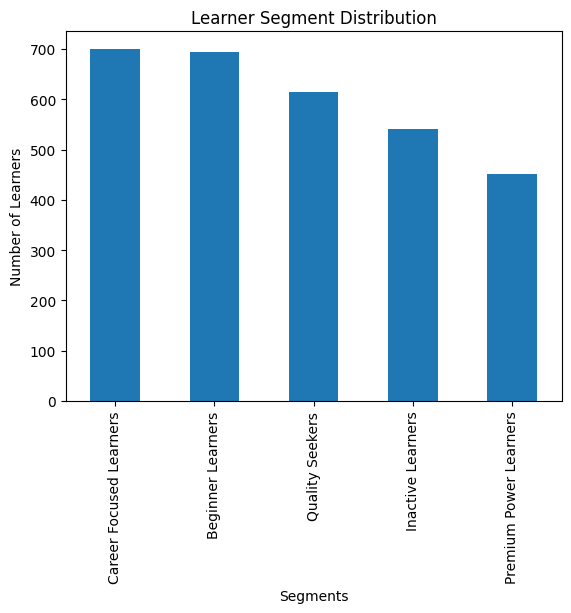

: 

In [ ]:
import matplotlib.pyplot as plt

learner_profile["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Learner Segment Distribution")

plt.xlabel("Segments")

plt.ylabel("Number of Learners")

plt.show()